1. Bibliotheques et preparation des donnees

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import OneHotEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

df = pd.read_csv("../data/df_features.csv")

print(f"Dataset prÃªt : {df.shape[0]:,} lignes & {df.shape[1]-1} features")


Dataset prÃªt : 118,614 lignes & 16 features


2. Split entrainement/test

In [2]:
#  test_size=0.25  : 75% train, 25% test
#  random_state=42 : rÃ©sultat identique Ã  chaque exÃ©cution
#  stratify=y : garantit ~5.4% de malicious dans train & test

X = df.drop(columns=["is_malicious"])
y = df["is_malicious"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.25,
    random_state = 42,
    stratify     = y
)

print(f"Train : {len(X_train):,} lignes  |  Test : {len(X_test):,} lignes")
print(f"% malicious train : {y_train.mean():.2%}")
print(f"% malicious test  : {y_test.mean():.2%}")



Train : 88,960 lignes  |  Test : 29,654 lignes
% malicious train : 5.38%
% malicious test  : 5.39%


3. Encodage

In [3]:
#Encodage par frÃ©quence
cols_freq = ["employee_position", "employee_origin_country"]

for col in cols_freq:
    freq_map     = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq_map)
    X_test[col]  = X_test[col].map(freq_map).fillna(freq_map.min())

#Pipeline : Encodage one-hot + StandardScaler
cols_onehot = ["employee_campus", "employee_department"]
cols_num    = [c for c in X_train.columns if c not in cols_onehot]

preprocessor = ColumnTransformer([
    ("one_hot",  OneHotEncoder(drop="first",
                               sparse_output=False,
                               handle_unknown="ignore"), cols_onehot),
    ("standard", StandardScaler(),                       cols_num),
])

4. Definiton des modeles

In [4]:
#  Par dÃ©faut : 3 variantes de Logistic Regression (C diffÃ©rents)
#  C petit : plus contraint 
#  C grand : plus libre

MODELES = {
    "LR  C=0.1  (rÃ©gularisation forte)" : LogisticRegression(
        C=0.1,  max_iter=1000, class_weight="balanced", random_state=42),

    "LR  C=1.0  (rÃ©gularisation normale)": LogisticRegression(
        C=1.0,  max_iter=1000, class_weight="balanced", random_state=42),

    "LR  C=10.0 (rÃ©gularisation faible)" : LogisticRegression(
        C=10.0, max_iter=1000, class_weight="balanced", random_state=42),
}

5. Entrainement & evaluation

In [5]:
resultats = []
pipelines = {}

for nom, clf in MODELES.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifieur",   clf)
    ])

    pipeline.fit(X_train, y_train)

    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    resultats.append({
        "ModÃ¨le"    : nom,
        "Accuracy"  : round(accuracy_score (y_test, y_pred),                  4),
        "Precision" : round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"    : round(recall_score   (y_test, y_pred, zero_division=0), 4),
        "F1"        : round(f1_score       (y_test, y_pred, zero_division=0), 4),
        "AUC-ROC"   : round(roc_auc_score  (y_test, y_proba),                 4),
    })

    pipelines[nom] = pipeline

    print(f"\n{'='*55}")
    print(f"  {nom}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=["Normal", "Malicious"]))





  LR  C=0.1  (rÃ©gularisation forte)
              precision    recall  f1-score   support

      Normal       0.98      0.86      0.92     28057
   Malicious       0.24      0.76      0.36      1597

    accuracy                           0.85     29654
   macro avg       0.61      0.81      0.64     29654
weighted avg       0.94      0.85      0.89     29654


  LR  C=1.0  (rÃ©gularisation normale)
              precision    recall  f1-score   support

      Normal       0.98      0.86      0.92     28057
   Malicious       0.24      0.77      0.36      1597

    accuracy                           0.85     29654
   macro avg       0.61      0.81      0.64     29654
weighted avg       0.94      0.85      0.89     29654


  LR  C=10.0 (rÃ©gularisation faible)
              precision    recall  f1-score   support

      Normal       0.98      0.86      0.92     28057
   Malicious       0.24      0.77      0.36      1597

    accuracy                           0.85     29654
   macro av

6. Tableau comparatif

In [6]:

resultats_df = pd.DataFrame(resultats)
print("COMPARAISON :")
print(resultats_df.to_string(index=False))

meilleur_nom      = resultats_df.sort_values("F1", ascending=False).iloc[0]["ModÃ¨le"]
meilleur_pipeline = pipelines[meilleur_nom]
print(f"\n Meilleure variante retenue : {meilleur_nom}")





COMPARAISON :
                             ModÃ¨le  Accuracy  Precision  Recall     F1  AUC-ROC
  LR  C=0.1  (rÃ©gularisation forte)    0.8538     0.2358  0.7646 0.3604   0.8739
LR  C=1.0  (rÃ©gularisation normale)    0.8533     0.2352  0.7652 0.3598   0.8743
 LR  C=10.0 (rÃ©gularisation faible)    0.8533     0.2352  0.7658 0.3599   0.8744

 Meilleure variante retenue : LR  C=0.1  (rÃ©gularisation forte)


In [7]:
y_pred_best  = meilleur_pipeline.predict(X_test)
y_proba_best = meilleur_pipeline.predict_proba(X_test)[:, 1]



7. Graphiques

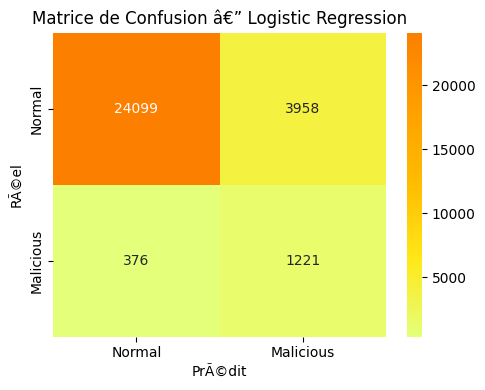

In [8]:
#Graphique 1 : Matrice de Confusion
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Wistia",
    xticklabels=["Normal", "Malicious"],
    yticklabels=["Normal", "Malicious"]
)
plt.title("Matrice de Confusion â€” Logistic Regression")
plt.ylabel("RÃ©el")
plt.xlabel("PrÃ©dit")
plt.tight_layout()
plt.show()

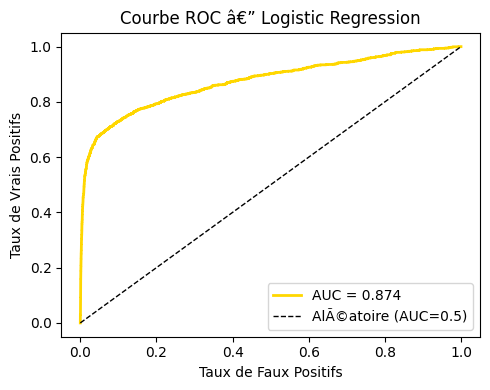

In [9]:
#Graphique 2 : Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="gold", lw=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="AlÃ©atoire (AUC=0.5)")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbe ROC â€” Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

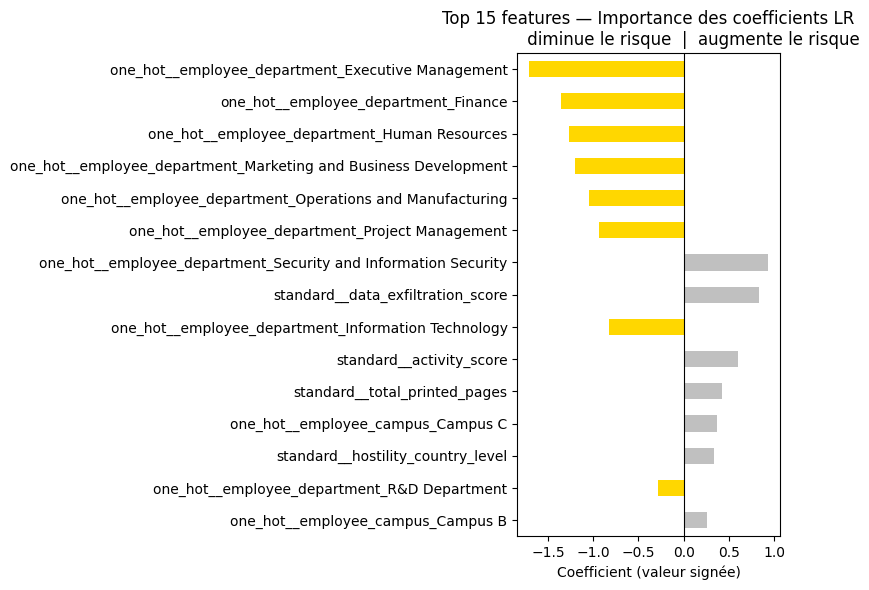

In [10]:
# Graphique 3 : Importance des features (coefficients)
clf  = meilleur_pipeline.named_steps["classifieur"]
prep = meilleur_pipeline.named_steps["preprocessing"]
noms = prep.get_feature_names_out()

coefs = pd.Series(clf.coef_[0], index=noms).reindex(
    pd.Series(np.abs(clf.coef_[0]), index=noms).sort_values().tail(15).index)

colors = ["silver" if v > 0 else "gold" for v in coefs.values]

plt.figure(figsize=(8, 6))
coefs.plot(kind="barh", color=colors)

plt.axvline(x=0, color="black", linewidth=0.8)

plt.title("Top 15 features — Importance des coefficients LR\n"
          "                 diminue le risque  |  augmente le risque")
plt.xlabel("Coefficient (valeur signée)")
plt.tight_layout()
plt.show()

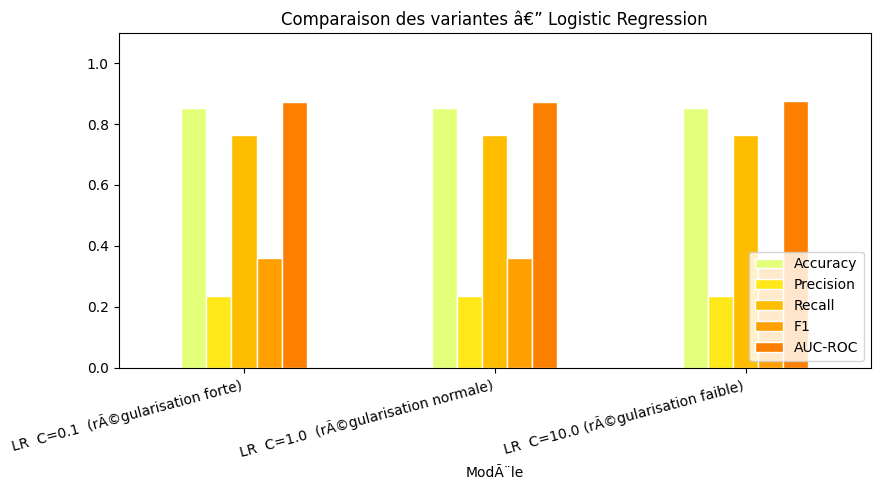

In [11]:
#Graphique 4 : Comparaison des variantes
resultats_df.set_index("ModÃ¨le")[["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]].plot(
    kind="bar", figsize=(9, 5),
    colormap="Wistia", edgecolor="white"
)
plt.ylim(0, 1.1)
plt.title("Comparaison des variantes â€” Logistic Regression")
plt.xticks(rotation=15, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [12]:
df.to_csv("../data/user_features.csv", index=False)

## 8. Sauvegarde du modèle

In [13]:
import joblib, json, os

os.makedirs("../models", exist_ok=True)

# ── 1. Freq maps (recalcul reproductible depuis données brutes) ──────────────
df_orig  = pd.read_csv("../data/df_features.csv")
X_raw    = df_orig.drop(columns=["is_malicious"])
y_raw    = df_orig["is_malicious"]
X_tr_raw, _, _, _ = train_test_split(X_raw, y_raw, test_size=0.25, random_state=42, stratify=y_raw)

freq_maps_save = {}
for col in ["employee_position", "employee_origin_country"]:
    fm = X_tr_raw[col].value_counts(normalize=True)
    freq_maps_save[col] = {str(k): float(v) for k, v in fm.items()}

with open("../models/freq_maps.json", "w") as f:
    json.dump(freq_maps_save, f, indent=2)

# ── 2. Pipeline ───────────────────────────────────────────────────────────────
joblib.dump(meilleur_pipeline, "../models/pipeline.pkl")

# ── 3. Métriques comparatives ─────────────────────────────────────────────────
with open("../models/metrics.json", "w", encoding="utf-8") as f:
    json.dump(resultats_df.to_dict(orient="records"), f, indent=2, ensure_ascii=False)

# ── 4. Données de performance (CM + ROC + importances) ───────────────────────
y_pred_s  = meilleur_pipeline.predict(X_test)
y_proba_s = meilleur_pipeline.predict_proba(X_test)[:, 1]
cm        = confusion_matrix(y_test, y_pred_s).tolist()
fpr, tpr, _ = roc_curve(y_test, y_proba_s)

clf_  = meilleur_pipeline.named_steps["classifieur"]
prep_ = meilleur_pipeline.named_steps["preprocessing"]
noms_ = list(prep_.get_feature_names_out())
coefs_= np.abs(clf_.coef_[0]).tolist()

perf_data = {
    "confusion_matrix": cm,
    "fpr": fpr.tolist(),
    "tpr": tpr.tolist(),
    "auc_roc": float(roc_auc_score(y_test, y_proba_s)),
    "feature_names": noms_,
    "feature_coefs": coefs_,
}
with open("../models/perf_data.json", "w") as f:
    json.dump(perf_data, f, indent=2)

# ── 5. Colonnes features ──────────────────────────────────────────────────────
with open("../models/feature_cols.json", "w") as f:
    json.dump(list(X_raw.columns), f)

print("✅  Modèle sauvegardé dans ../models/")
print("    pipeline.pkl  |  freq_maps.json  |  metrics.json  |  perf_data.json  |  feature_cols.json")


✅  Modèle sauvegardé dans ../models/
    pipeline.pkl  |  freq_maps.json  |  metrics.json  |  perf_data.json  |  feature_cols.json
